In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import jax.numpy as jnp
import numpy as np
import arviz as az
import healpy as hp

sys.path.append("../..")
from utils.multi_corner import multi_corner
from utils.validation import find_hdi_prob, roc_finite_sample_band

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../notebooks/matplotlibrc")

In [2]:
import numpyro
from numpyro.infer import SVI, Trace_ELBO, Predictive
import jax
from jax.example_libraries import stax
from numpyro.infer import autoguide
from numpyro import handlers

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
truth_dict = {
    'Sps_dsk' : 1.3,
    'zs' : 0.5,
    'C' : 2.5,
    'n1_dsk' : 5.0,
    'n2_dsk' : 1.3,
    'n3_dsk' : -5.4,
    'sb1_dsk' : 11.,
    'lambdas_dsk' : 0.4,
}

## 1. templates and masks

In [4]:
from models.templates import NFWTemplate, LorimerDiskTemplate
from utils import create_mask as cm

In [5]:
disk_template = LorimerDiskTemplate(nside=128)
z = disk_template.get_template(zs=truth_dict['zs'], C=truth_dict['C'])

In [6]:
data_dir = '../../data'
nside = 128

mask_ps = hp.ud_grade(np.load(f"{data_dir}/mask_3fgl_0p8deg.npy"), nside_out=nside) > 0
mask_roi = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=25, custom_mask=mask_ps)
mask_plane = cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=25,)

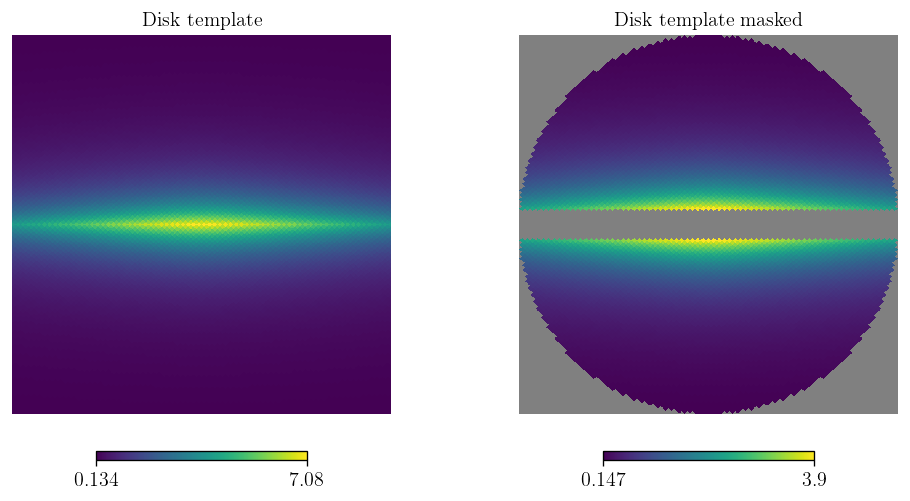

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

plt.sca(axs[0])
hp.cartview(z, latra=[-25, 25], lonra=[-25, 25], hold=True, title='Disk template')

plt.sca(axs[1])
z_plot = np.array(z)
z_plot[mask_plane] = hp.UNSEEN
hp.cartview(z_plot, latra=[-25, 25], lonra=[-25, 25], hold=True, title='Disk template masked')

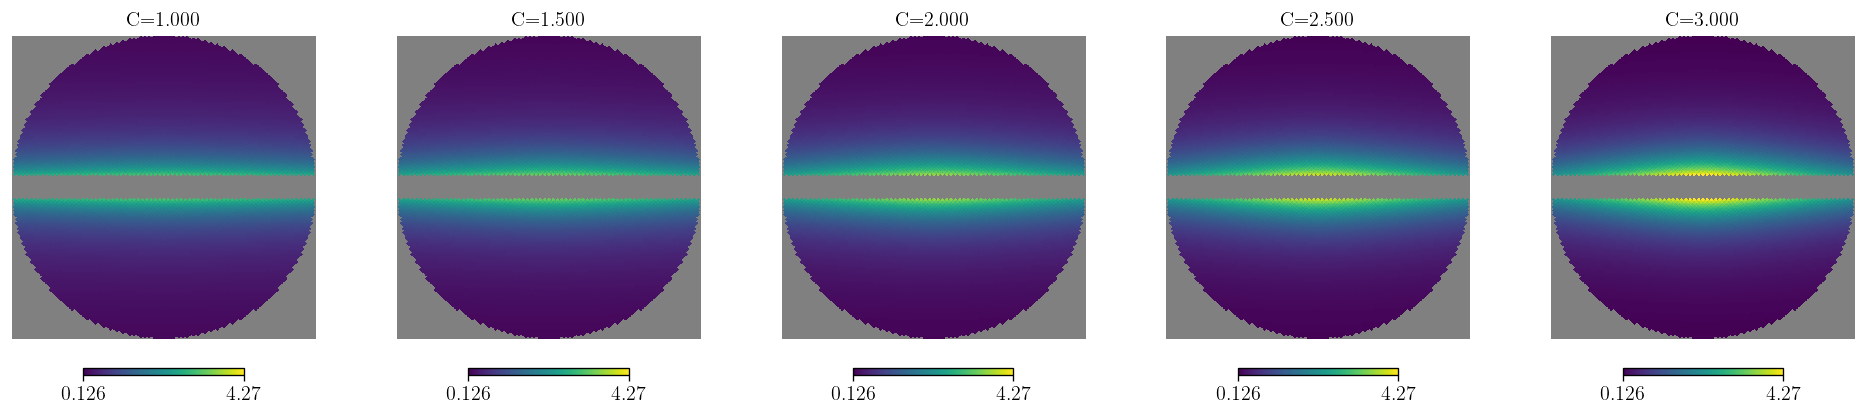

In [23]:
# varying C
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

C_s = [1.0, 1.5, 2.0, 2.5, 3.0]

for i in range(5):
    plt.sca(axs[i])
    z = disk_template.get_template(zs=truth_dict['zs'], C=C_s[i])
    z_plot = np.array(z)
    z_plot[mask_plane] = hp.UNSEEN
    hp.cartview(z_plot, latra=[-25, 25], lonra=[-25, 25], hold=True, title=f'C={C_s[i]:.3f}', max=4.27, min=0.126)

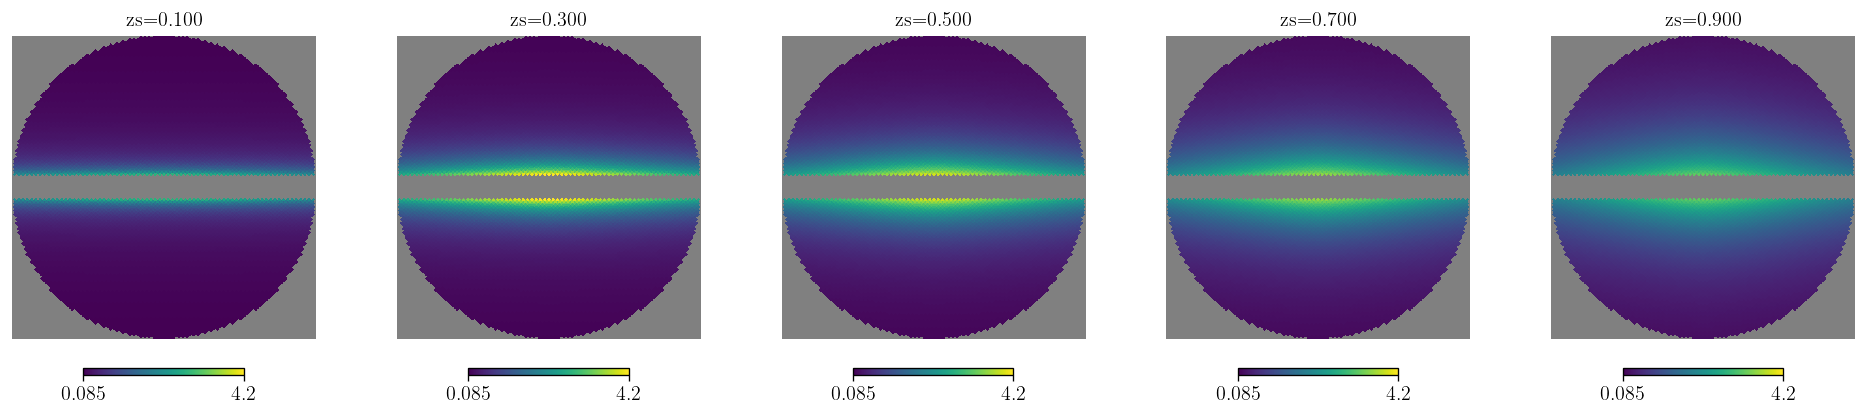

In [25]:
# varying zs
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

zs_s = [0.1, 0.3, 0.5, 0.7, 0.9]

for i in range(5):
    plt.sca(axs[i])
    z = disk_template.get_template(zs=zs_s[i], C=truth_dict['C'])
    z_plot = np.array(z)
    z_plot[mask_plane] = hp.UNSEEN
    hp.cartview(z_plot, latra=[-25, 25], lonra=[-25, 25], hold=True, title=f'zs={zs_s[i]:.3f}', max=4.2, min=0.085)

## 2. Simulate

In [7]:
from simulations.wrapper import simulator
from models.psf import KingPSF

In [8]:
def simulate():
    vd = truth_dict
    nm = mask_plane
    temps_poiss = [np.ones(hp.nside2npix(nside))]
    theta = [0.,]
    
    temp_ps_dsk = disk_template.get_template(zs=vd['zs'], C=vd['C'])
    temp_ps_dsk /= np.mean(temp_ps_dsk[~nm])
    temps_ps = []
    temps_ps.append(np.array(temp_ps_dsk))
    theta += [vd['Sps_dsk'], vd['n1_dsk'], vd['n2_dsk'], vd['n3_dsk'], vd['sb1_dsk'], vd['lambdas_dsk'] * vd['sb1_dsk']]

    mask_sim = np.array(nm)
    mask_normalize_counts = mask_sim
    exp_map = np.ones(hp.nside2npix(nside))

    kp = KingPSF()
    psf_r_func = lambda r: kp.psf_fermi_r(r)
    return simulator(theta, temps_poiss, temps_ps, mask_sim, mask_normalize_counts, mask_roi, psf_r_func, exp_map)[0]

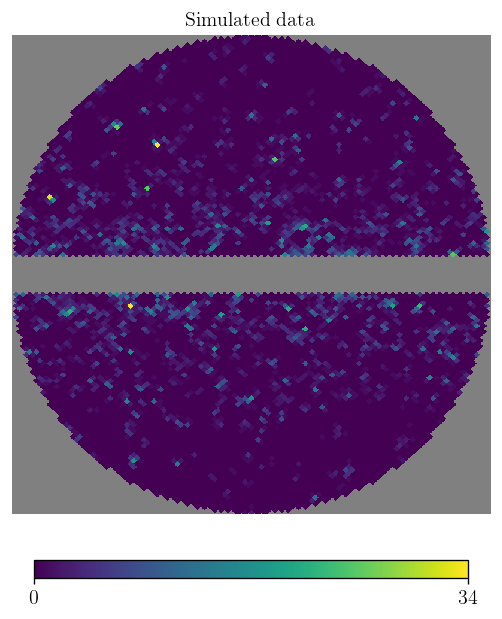

In [27]:
z = simulate()
z_plot = np.zeros(hp.nside2npix(nside))
z_plot[~mask_plane] = z
z_plot[mask_plane] = hp.UNSEEN
hp.cartview(z_plot, latra=[-25, 25], lonra=[-25, 25], title='Simulated data')

In [9]:
dataset = []
for _ in tqdm(range(30)):
    dataset.append(simulate())

  0%|          | 0/30 [00:00<?, ?it/s]

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3662: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "
100%|██████████| 30/30 [00:23<00:00,  1.29it/s]


## 3. Model & SVI

In [10]:
import numpyro.distributions as dist
from models.scd import dnds
from likelihoods.npll_jax import log_like_np
from nptfit_func import psf_corr

In [11]:
kp = KingPSF()
f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = kp.psf_fermi_r, num_f_bins=30)

In [12]:
data = jnp.ones(hp.nside2npix(nside), dtype=jnp.int32)[~mask_roi]

theta = jnp.array([[1.3, 5.0, 1.3, -5.4, 11., 0.4 * 11.]])
pt_sum_compressed = jnp.full_like(data, 1e-10)

npt_compressed = jnp.array([disk_template.get_template(zs=0.5, C=2.5)[~mask_roi]])

k_max = 10
npixROI = np.sum(~mask_roi)

log_like_np(theta, pt_sum_compressed, npt_compressed, data, f_ary, df_rho_div_f_ary, k_max, npixROI)

Array([-7.76130235, -7.76049195, -7.75831025, ..., -7.76130235,
       -7.76049195, -7.75831025], dtype=float64)

In [23]:
len(mask_roi)

196608

In [64]:
def model(data=data, k_max=0, npixROI=0):
    # data is unmasked

    # general setting
    nm = mask_plane
    m = mask_roi
    data_in = data[~m]

    # poisson
    mu = jnp.full_like(data, 1e-10)[~m]

    # disk: param
    zs = numpyro.sample("zs", dist.Uniform(0.1, 2.0))
    C = numpyro.sample("C", dist.Uniform(0.05, 8.))
    temp_dsk = disk_template.get_template(zs=zs, C=C)

    # disk: normalization
    A_dsk = 1 / jnp.mean(temp_dsk[~nm])
    temp_dsk = A_dsk * temp_dsk
    npt_compressed = jnp.array([temp_dsk])

    # disk: scd
    theta = []
    vd = truth_dict
    for ips, ps in enumerate(["dsk"]):

        Sps = numpyro.sample("Sps_{}".format(ps), dist.Uniform(1e-3, 4.))
        # n1 = numpyro.sample("n1_{}".format(ps), dist.Uniform(4.0, 6.0))
        # n2 = numpyro.sample("n2_{}".format(ps), dist.Uniform(0.5, 1.99))
        # n3 = numpyro.sample("n3_{}".format(ps), dist.Uniform(-6., -5.))
        # sb1 = numpyro.sample("sb1_{}".format(ps), dist.Uniform(5., 40.0))
        # lambda_s = numpyro.sample("lambdas_{}".format(ps), dist.Uniform(0.1, 0.95))
        n1 = vd['n1_dsk']
        n2 = vd['n2_dsk']
        n3 = vd['n3_dsk']
        sb1 = vd['sb1_dsk']
        lambda_s = vd['lambdas_dsk']

        theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
        s_ary = jnp.logspace(-1., 2., 100)
        dnds_ary = dnds(s_ary, theta_tmp)
        A = Sps / jnp.mean(npt_compressed[ips][~nm] * jnp.trapz(s_ary * dnds_ary, s_ary))
        theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])
    theta = jnp.array(theta)

    npt_compressed_in = jnp.array([temp_dsk[~m]])
            
    with numpyro.plate("data", size=len(mu), dim=-1):
        
        # print(type(k_max))
        # print(type(npixROI))

        ll = log_like_np(theta, mu, npt_compressed_in, data_in, f_ary, df_rho_div_f_ary, k_max, npixROI)

        with handlers.mask(mask=~jnp.logical_or(jnp.isinf(ll), jnp.isnan(ll))):
            return numpyro.factor('log-likelihood', ll)

In [52]:
# test model
with handlers.seed(rng_seed=123):
    model(jnp.ones(hp.nside2npix(nside), dtype=jnp.int32))

<class 'int'>
<class 'int'>


## 4. Fit

In [14]:
import optax
from numpyro import optim

In [73]:
def fit_svi(
    model,
    rng_key=jax.random.PRNGKey(42),
    num_flows=5, hidden_dims=[128, 128],
    n_steps=5000, lr=5e-4, num_particles=8, vectorize_particles=True,
    **model_static_kwargs
):
    iaf_kwargs = dict(num_flows=num_flows, hidden_dims=hidden_dims, nonlinearity=stax.Tanh)
    guide = autoguide.AutoIAFNormal(model, **iaf_kwargs)
    optimizer = optim.optax_to_numpyro(optax.chain(optax.clip(1.), optax.adam(lr)))
    svi = SVI(model, guide, optimizer, Trace_ELBO(num_particles=num_particles, vectorize_particles=vectorize_particles))
    svi_results = svi.run(rng_key, n_steps, **model_static_kwargs)
    
    return svi_results, guide

In [ ]:
def fit_and_get_samples(norm_masked_data, rng_key):
    data_in = np.zeros(hp.nside2npix(nside), dtype=np.int32)
    data_in[~mask_plane] = norm_masked_data
    data_in = jnp.asarray(data_in, dtype=jnp.int32)
    k_max = int(np.max(data_in))
    npixROI = int(np.sum(~mask_roi))

    key, subkey = jax.random.split(rng_key)
    svi_results, guide = fit_svi(model, rng_key=subkey, data=jnp.asarray(data_in), k_max=k_max, npixROI=npixROI)

    sample = guide.sample_posterior(
        rng_key=key,
        params=svi_results.params,
        sample_shape=(50000,)
    )
    return svi_results, sample

In [74]:
data_in = np.zeros(hp.nside2npix(nside), dtype=np.int32)
data_in[~mask_plane] = dataset[0]
data_in = jnp.asarray(data_in, dtype=jnp.int32)

k_max = int(np.max(data_in))
npixROI = int(np.sum(~mask_roi))

svi_results, guide = fit_svi(model, data=jnp.asarray(data_in), k_max=k_max, npixROI=npixROI)

100%|██████████| 5000/5000 [03:02<00:00, 27.32it/s, init loss: 9415.8236, avg. loss [4751-5000]: 7909.4201]


[]

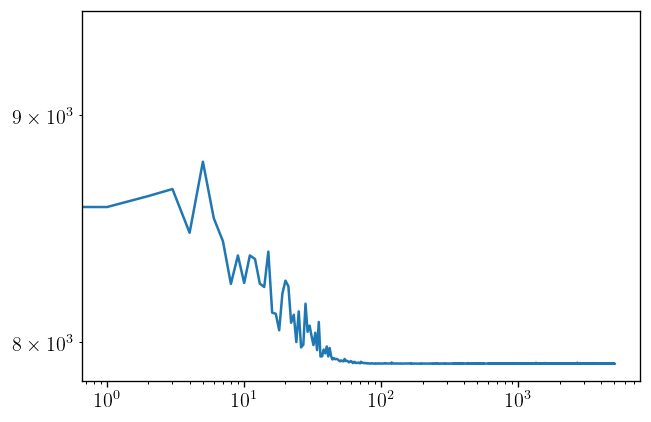

In [75]:
plt.plot(svi_results.losses)
plt.loglog()

In [76]:
sample = guide.sample_posterior(
    rng_key=jax.random.PRNGKey(42),
    params=svi_results.params,
    sample_shape=(50000,)
)

## 5. Posteriors

In [5]:
sample = pickle.load(open("base/hmc_samples_0.p", "rb"))

In [6]:
samples_dict = {'0' : sample}

valid_i_s = samples_dict.keys()
colors_dict = {i_str: cms['viridis'](float(i_str)/(10-1)) for i_str in valid_i_s}
labels_dict = {i_str: i_str for i_str in valid_i_s}
print(samples_dict['0'].keys())

dict_keys(['C', 'Sps_dsk', 'zs'])


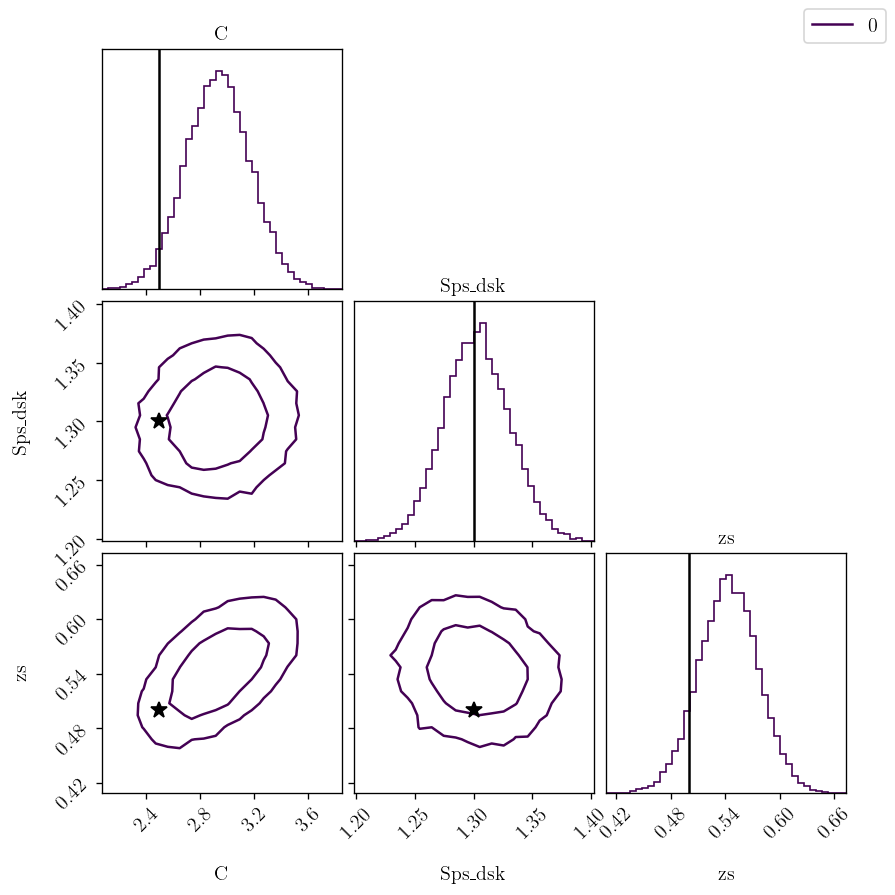

In [7]:
# plot_var_names = [
#     'Sps_dsk', 'Sps_gce', 'gamma_ps', 'zs', 'C'
# ]
plot_var_names = list(samples_dict['0'].keys())
#logging.getLogger().setLevel(logging.ERROR)
multi_corner(
    samples_dict, plot_var_names,
    colors_dict=colors_dict, labels_dict=labels_dict,
    point_est=truth_dict,
    hist_bin_factor=2, save_fn=None
)

## 6. Coverage